ARMA forecasting per bridge

In [1]:
! pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
DATA_PATH = "2017 Monthly Bike Count Totals for East River Bridges"

In [5]:
def load_data():
    dfs = []

    for f in os.listdir(DATA_PATH):
        if f.endswith(".xlsx"):

            df = pd.read_excel(
                os.path.join(DATA_PATH, f),
                header=5,
                usecols="B:K"
            )

            df.columns = df.columns.str.lower()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df[df["date"].notna()]

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values("date")
    df = df.reset_index(drop=True)

    return df

In [6]:
df = load_data()
df

,date,day,high temp (°f),low temp (°f),precipitation,brooklyn bridge,manhattan bridge,williamsburg bridge,queensboro bridge,total
0,2017-04-01,2017-04-01 00:00:00,46.0,37,0,606.0,1446,1915.0,1430.0,5397
1,2017-04-02,2017-04-02 00:00:00,62.1,41,0,2021.0,3943,4207.0,2862.0,13033
2,2017-04-03,2017-04-03 00:00:00,63.0,50,0.03,2470.0,4988,5178.0,3689.0,16325
3,2017-04-04,2017-04-04 00:00:00,51.1,46,1.18,723.0,1913,2279.0,1666.0,6581
4,2017-04-05,2017-04-05 00:00:00,63.0,46,0,2807.0,5276,5711.0,4197.0,17991
...,...,...,...,...,...,...,...,...,...,...
209,2017-10-27,2017-10-27 00:00:00,62.1,48,0,3150.0,5610,6450.0,5181.0,20391
210,2017-10-28,2017-10-28 00:00:00,68.0,55.9,0,2245.0,4520,5104.0,4069.0,15938
211,2017-10-29,2017-10-29 00:00:00,64.9,61,3.03,183.0,661,1026.0,965.0,2835
212,2017-10-30,2017-10-30 00:00:00,55.0,46,0.25,1428.0,2966,3547.0,2924.0,10865


In [7]:
def train_test_split(series, test_size=0.3):
    split = int(len(series) * (1 - test_size))
    return series[:split], series[split:]

In [8]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [9]:
def run_arma(series, bridge_name):
    train, test = train_test_split(series)

    model = ARIMA(train, order=(7, 0, 7))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=len(test))

    mae, rmse = evaluate(test.values, forecast.values)

    print(f"\n=== ARMA - {bridge_name} ===")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    plt.figure()
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, forecast, label="Forecast")
    plt.title(f"ARMA Forecast - {bridge_name}")
    plt.legend()
    plt.show()

In [10]:
bridges = [
    "brooklyn bridge",
    "manhattan bridge",
    "williamsburg bridge",
    "queensboro bridge"
]


Running ARMA for brooklyn bridge

=== ARMA - brooklyn bridge ===
MAE: 562.49, RMSE: 809.67


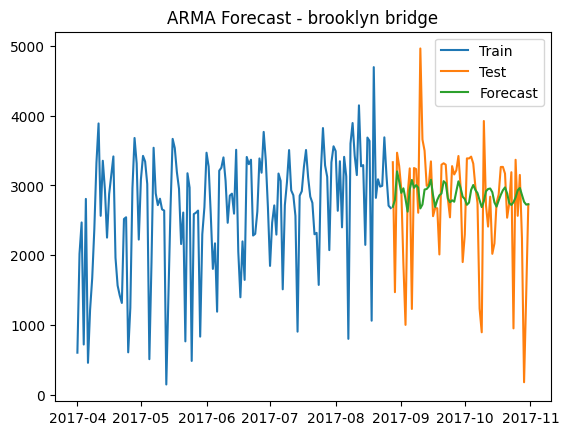


Running ARMA for manhattan bridge

=== ARMA - manhattan bridge ===
MAE: 1062.22, RMSE: 1428.43


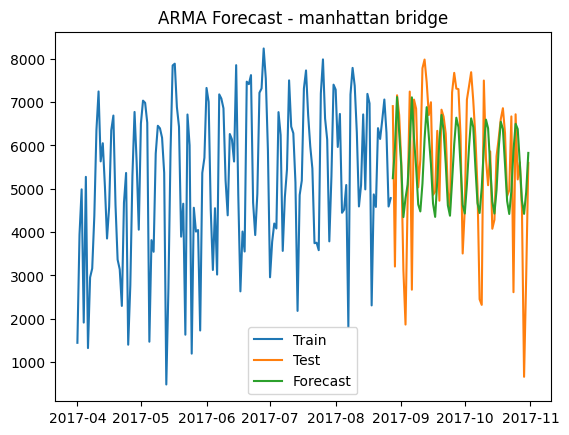


Running ARMA for williamsburg bridge

=== ARMA - williamsburg bridge ===
MAE: 1090.38, RMSE: 1457.00


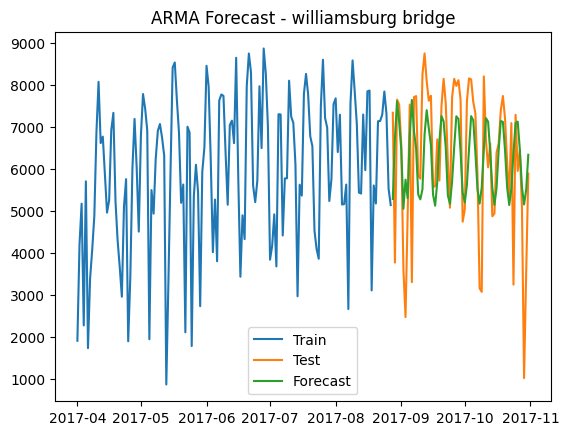


Running ARMA for queensboro bridge

=== ARMA - queensboro bridge ===
MAE: 743.69, RMSE: 1039.68


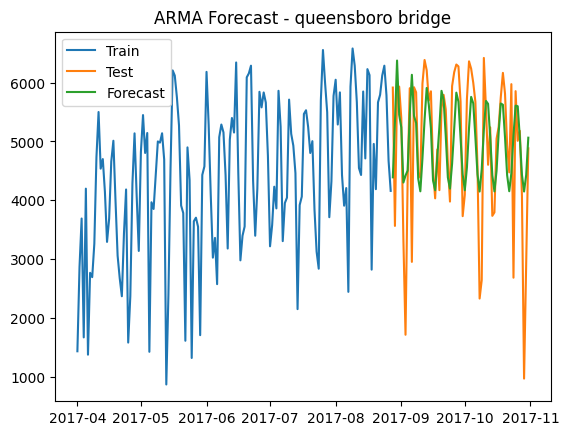

In [11]:
for bridge in bridges:
    print(f"\nRunning ARMA for {bridge}")
    df[bridge] = df[bridge].astype(float)
    series = df.set_index("date")[bridge].dropna()
    run_arma(series, bridge)